# 10 · A state matrix from a spiking layer

**What you will do:** drive a layer of adaptive exponential integrate-and-fire neurons with the raw SHD spike trains, take one population vector per presentation, stack those into a state matrix, and train a decoder on it.

**What you should take away:** the encoder / circuit / readout pattern in its standard form, and what a single state vector can and cannot carry. The filter time constant is that vector's memory, and pushing it far enough turns the state into a rate code — at which point you have thrown away the thing the circuit was supposed to preserve.

This is the same model as notebook 9 with a different readout. There, every time bin of the response was a feature. Here each presentation is summarised by **one** vector, which is what a reservoir readout, a delayed-match task, or any experiment with one measurement per trial actually gives you.

Runtime: four to ten minutes depending on what else the machine is doing. The trial-by-trial loop is nearly all of it.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import jax
import jax.numpy as jnp
from jaxley.channels import AdEx

from compbio2026 import data, decoding, filters, geometry, plotting, spiking

plotting.apply_style()
rng = np.random.default_rng(2026)

SIM_DT = 0.1            # ms, integration timestep
T_MAX = 700.0           # ms, real trial duration
N_CELLS = 100           # AdEx neurons in the layer
FAN_IN = 60             # SHD channels converging on each of them
G_SYN = 3e-5            # uS per synapse
SPIKE_THRESHOLD = -20.0  # mV; AdEx caps the membrane at 0 mV, so 0 would never trigger

TAU_MS = 200.0          # ms, decay of the filtered state
SAMPLE_AT = 500.0       # ms, when the representative vector is read out
SAMPLE_TIMES = np.arange(100.0, T_MAX + 1.0, 50.0)

DIGITS = ["one", "three", "six", "seven"]
N_PER = 40

In [2]:
shd = data.load("train")
idx = np.concatenate([
    rng.choice(np.flatnonzero(shd.labels == data.DIGIT_KEYS.index(d)), N_PER, replace=False)
    for d in DIGITS
])
y = np.repeat(np.arange(len(DIGITS)), N_PER)
order = rng.permutation(len(idx))
idx, y = idx[order], y[order]

print(f"{len(idx)} presentations, {len(DIGITS)} classes, chance = {decoding.chance_level(y):.3f}")

160 presentations, 4 classes, chance = 0.250


## The layer

```
SHD spikes  ->  conductance synapses  ->  AdEx layer  ->  spikes  ->  filtered state  ->  one vector per trial
 700 channels     tonotopic fan-in        100 cells                     tau = 200 ms        read at 500 ms
```

Notebooks 8 and 9 used Hodgkin–Huxley cells. This one uses **AdEx**, the adaptive exponential integrate-and-fire model: a leak, an exponential spike-generating current, and an adaptation variable. It simulates about fifteen times faster than HH, which is what makes a trial-by-trial loop over the whole dataset comfortable. The cost is that its gradients are zero after every spike, so you can run this model but you cannot train through it — which is fine here, because only the readout is trained.

JAXley's AdEx defaults need rescaling for the compartment used in this project. They assume a much smaller cell: `g_L` of 10 S/cm² against a capacitance of 1 uF/cm² gives a membrane time constant of 0.1 microseconds, so the cell integrates nothing and stays silent however hard you drive it. `spiking.ADEX_PARAMS` sets conductance densities that put the time constant at 20 ms instead. Check that against `net.nodes` if you change the compartment geometry.

In [3]:
M = spiking.tonotopic_connectivity(700, N_CELLS, fan_in=FAN_IN, width=35.0,
                                   rng=np.random.default_rng(0))
net = spiking.build_layer(M, channel=AdEx(surrogate_warning=False),
                          channel_params=spiking.ADEX_PARAMS, tau_syn_ms=5.0)
n_edges = len(net.edges)
sim = jax.jit(spiking.make_simulator(net, n_in=700, dt_ms=SIM_DT))
g_syn = jnp.full((n_edges,), G_SYN)
print(f"{n_edges} synapses onto {N_CELLS} AdEx cells")

6000 synapses onto 100 AdEx cells


## The loop

One presentation at a time, and nothing is batched. This is deliberately the literal version of the experiment: present a stimulus, let the circuit run, look at its state, write the state down, move on.

Four steps per iteration, and each one is a modelling decision:

1. **Drive** — the raw event list of that trial as a presynaptic voltage clamp. No binning beyond the 0.1 ms simulation grid.
2. **Simulate and record** — integrate the layer and detect its spikes. Threshold at −20 mV, because AdEx caps the membrane at 0 mV and resets, so the HH default of 0 would find nothing.
3. **Filter** — `filters.exponential_state` is the recursive form of the exponential kernel: a state variable decayed and kicked at each timestep rather than a convolution computed afterwards. That is what a synapse does, and at `dt = 0.1 ms` with a 200 ms time constant it is also two orders of magnitude cheaper than the explicit kernel.
4. **Sample** — read the filtered state at a set of times. The state at `SAMPLE_AT` is the representative vector; keeping the others costs nothing and lets the last section ask when to look.

The spike trains are kept as well, so the sweeps below can re-filter without re-simulating.

In [4]:
sample_idx = (SAMPLE_TIMES / SIM_DT).astype(int) - 1
k_default = int(np.argmin(np.abs(SAMPLE_TIMES - SAMPLE_AT)))

spikes, sampled = [], []
t0 = time.time()
for n, trial in enumerate(idx):
    drive = spiking.spike_drive(shd, [trial], dt_ms=SIM_DT, t_max_ms=T_MAX)[0]   # 1 · drive
    v = np.asarray(sim(g_syn, jnp.array(drive)))                                 # 2 · simulate
    spk = spiking.detect_spikes(v, threshold=SPIKE_THRESHOLD)                    #     and record
    state = filters.exponential_state(spk[None].astype(np.float32),              # 3 · filter
                                      tau_ms=TAU_MS, dt_ms=SIM_DT)[0]
    spikes.append(spk)
    sampled.append(state[:, sample_idx])                                         # 4 · sample
    if (n + 1) % 40 == 0:
        print(f"  {n + 1:3d}/{len(idx)} presentations  {time.time() - t0:5.0f}s")

spikes = np.stack(spikes)          # (trials, cells, timesteps)
sampled = np.stack(sampled)        # (trials, cells, sampling times)
X = sampled[:, :, k_default]       # the state matrix: one vector per presentation
print()
print(f"simulated {len(idx)} presentations in {time.time() - t0:.0f}s "
      f"({(time.time() - t0) / len(idx):.2f} s each)")
print(f"mean output rate {spikes.sum() / len(idx) / N_CELLS / (T_MAX / 1e3):.1f} Hz, "
      f"{int((spikes.sum(axis=(0, 2)) == 0).sum())} silent cells")
print(f"state matrix X: {X.shape} = (presentations, cells)")

   40/160 presentations    173s


   80/160 presentations    342s


  120/160 presentations    495s


  160/160 presentations    633s

simulated 160 presentations in 634s (3.96 s each)


mean output rate 15.8 Hz, 0 silent cells
state matrix X: (160, 100) = (presentations, cells)


## One presentation, end to end

Input spikes, the layer's response, and the filtered state that the readout sees. The vertical line marks `SAMPLE_AT`: everything to the right of it is invisible to the state matrix, and everything to the left is weighted by how long ago it happened.

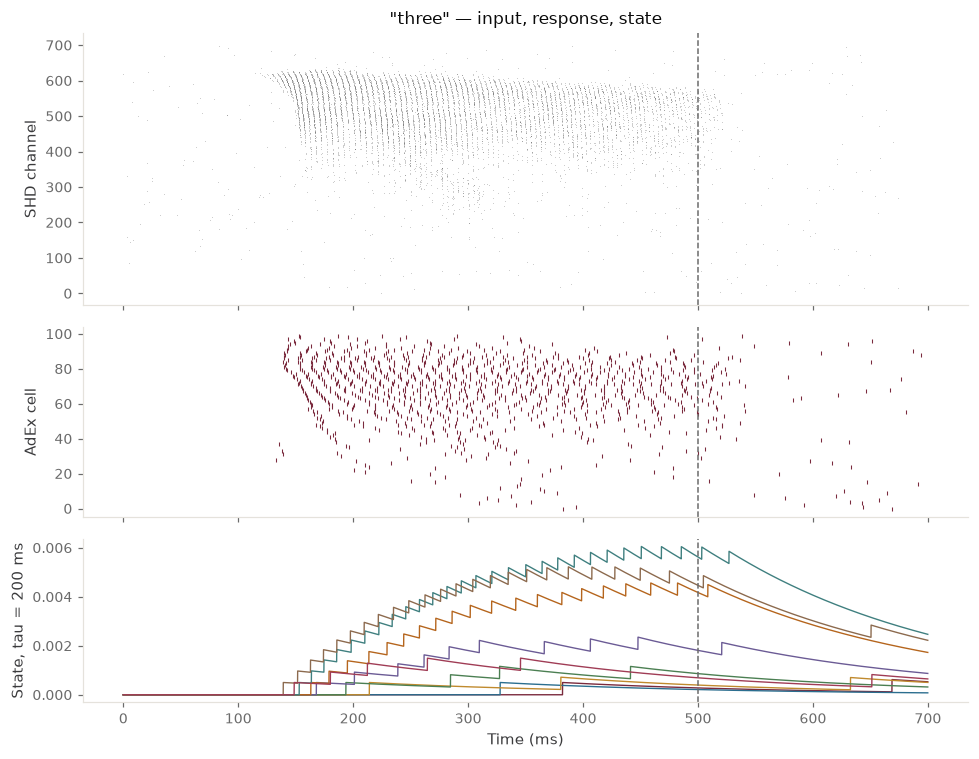

In [5]:
ex = 0
tt = np.arange(spikes.shape[2]) * SIM_DT
state_ex = filters.exponential_state(spikes[ex][None].astype(np.float32),
                                     tau_ms=TAU_MS, dt_ms=SIM_DT)[0]

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1.4, 1.2]})
ev = data.events(shd, idx[ex], t_max_ms=T_MAX)
axes[0].scatter(ev[:, 1], ev[:, 0], s=0.4, c=plotting.INK, marker=".", linewidths=0, alpha=0.6)
axes[0].set_ylabel("SHD channel")
axes[0].set_title(f'"{DIGITS[y[ex]]}" — input, response, state')

cell, step = np.nonzero(spikes[ex])
axes[1].scatter(step * SIM_DT, cell, s=4, c=plotting.ACCENT, marker="|", linewidths=0.7)
axes[1].set_ylabel("AdEx cell")

for i in range(0, N_CELLS, 12):
    axes[2].plot(tt, state_ex[i], lw=0.9)
axes[2].set_ylabel(f"State, tau = {TAU_MS:.0f} ms")
axes[2].set_xlabel("Time (ms)")

for ax in axes:
    ax.axvline(SAMPLE_AT, color=plotting.INK_MUTED, ls="--", lw=1)
fig.tight_layout()
plotting.savefig(fig, "10_one_presentation", outdir="../plots")

## The state matrix

`(160, 100)`: one row per presentation, one column per cell. Sorted by class here purely so the structure is visible — the decoder sees the rows in a random order and never uses the labels except to fit.

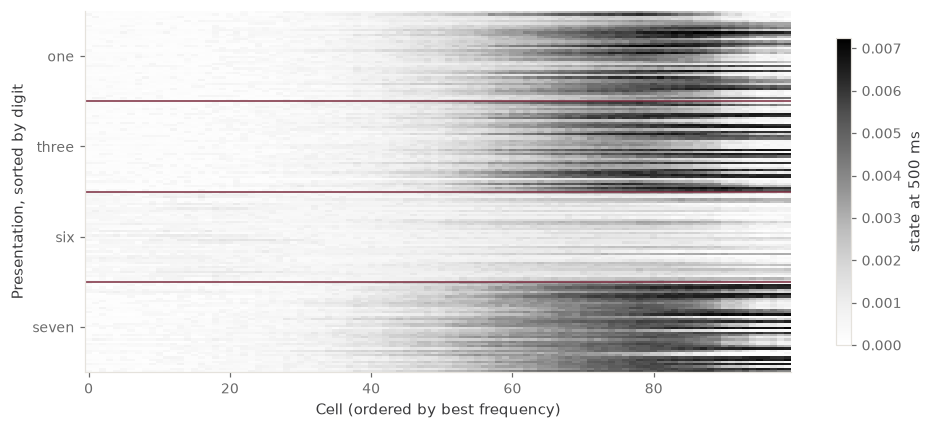

In [6]:
srt = np.argsort(y, kind="stable")
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(X[srt], aspect="auto", cmap="Greys", interpolation="nearest")
for b in np.flatnonzero(np.diff(y[srt])) + 1:
    ax.axhline(b - 0.5, color=plotting.ACCENT, lw=1)
ax.set_xlabel("Cell (ordered by best frequency)")
ax.set_ylabel("Presentation, sorted by digit")
ax.set_yticks([np.mean(np.flatnonzero(y[srt] == i)) for i in range(len(DIGITS))])
ax.set_yticklabels(DIGITS)
fig.colorbar(im, ax=ax, shrink=0.85, label=f"state at {SAMPLE_AT:.0f} ms")
fig.tight_layout()
plotting.savefig(fig, "10_state_matrix", outdir="../plots")

In [7]:
readout = decoding.make_readout("ridge")
result = decoding.decode(X, y, estimator=readout)
null = decoding.shuffle_control(X, y, estimator=readout)

print(f"state matrix        {result['mean']:.3f} +/- {result['std']:.3f}")
print(f"shuffled labels     {null.mean():.3f} +/- {null.std():.3f}")
print(f"chance              {result['chance']:.3f}")
print()
print(pd.Series(geometry.summarize(X, y)).round(3).to_string())

state matrix        0.725 +/- 0.080
shuffled labels     0.230 +/- 0.029
chance              0.250

participation_ratio       1.546
class_separation          0.641
between_class_distance    0.010
within_class_radius       0.008


## When to look, and how long the memory should be

Two parameters were fixed above and neither was justified. `SAMPLE_AT` decides when the state is read; `TAU_MS` decides how much of the past that state still contains. They interact, so sweep them together.

Re-filtering the stored spike trains is cheap, so this costs no extra simulation.

tau_ms,30.0,100.0,200.0,400.0,800.0
sample_ms,,,,,
100.0,0.562,0.556,0.556,0.531,0.538
150.0,0.406,0.481,0.519,0.519,0.525
200.0,0.406,0.500,0.544,0.569,0.581
250.0,0.388,0.488,0.556,0.581,0.606
300.0,0.406,0.519,0.562,0.594,0.638
350.0,0.375,0.488,0.550,0.631,0.638
400.0,0.388,0.538,0.600,0.656,0.675
450.0,0.412,0.550,0.650,0.725,0.712
500.0,0.369,0.544,0.725,0.750,0.769


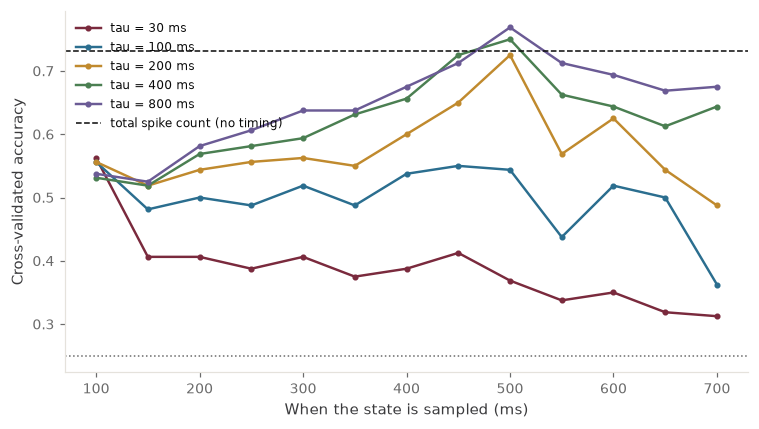

In [8]:
rows = []
for tau in [30.0, 100.0, 200.0, 400.0, 800.0]:
    F = filters.exponential_state(spikes.astype(np.float32), tau_ms=tau, dt_ms=SIM_DT)
    for k, t_s in zip(sample_idx, SAMPLE_TIMES):
        rows.append({"tau_ms": tau, "sample_ms": t_s,
                     "accuracy": decoding.decode(F[:, :, k], y, estimator=readout)["mean"]})
sweep = pd.DataFrame(rows)

count_only = decoding.decode(spikes.sum(axis=2).astype(np.float32), y, estimator=readout)["mean"]

fig, ax = plt.subplots(figsize=(7, 4))
for tau, grp in sweep.groupby("tau_ms"):
    ax.plot(grp["sample_ms"], grp["accuracy"], marker="o", ms=3, label=f"tau = {tau:.0f} ms")
ax.axhline(count_only, ls="--", lw=1, color=plotting.INK,
           label="total spike count (no timing)")
ax.axhline(decoding.chance_level(y), ls=":", lw=1, color=plotting.INK_MUTED)
ax.set_xlabel("When the state is sampled (ms)")
ax.set_ylabel("Cross-validated accuracy")
ax.legend(fontsize=8)
fig.tight_layout()
plotting.savefig(fig, "10_sampling_sweep", outdir="../plots")

sweep.pivot(index="sample_ms", columns="tau_ms", values="accuracy").round(3)

In [9]:
best = sweep.loc[sweep["accuracy"].idxmax()]
mean_state = decoding.decode(
    filters.exponential_state(spikes.astype(np.float32), tau_ms=TAU_MS, dt_ms=SIM_DT).mean(axis=2),
    y, estimator=readout)["mean"]

print(f"default (tau {TAU_MS:.0f} ms, sampled at {SAMPLE_AT:.0f} ms)  {result['mean']:.3f}")
print(f"best point of the sweep                       {best['accuracy']:.3f}  "
      f"(tau {best['tau_ms']:.0f} ms at {best['sample_ms']:.0f} ms)")
print(f"trial-mean of the filtered state              {mean_state:.3f}")
print(f"total spike count per cell, no timing at all  {count_only:.3f}")
print(f"chance                                        {decoding.chance_level(y):.3f}")

default (tau 200 ms, sampled at 500 ms)  0.725
best point of the sweep                       0.769  (tau 800 ms at 500 ms)
trial-mean of the filtered state              0.806
total spike count per cell, no timing at all  0.731
chance                                        0.250


## What one vector can carry

The sweep has a clear shape and an awkward conclusion.

Accuracy climbs with `tau` at almost every sampling time, and the best sampling time drifts later as `tau` grows. That is what a decaying memory does: with a 30 ms time constant the state at 500 ms reflects the last 30 ms of a word that has been arriving for hundreds, and the rest has leaked away. The best point of the sweep uses a time constant longer than the trial itself, at which point the state barely decays within the presentation and is close to a running total.

Now compare the three ways of turning a presentation into one vector. The best snapshot, the trial-mean of the filtered state, and the plain total spike count per cell — which contains no timing information whatsoever — all land within about one standard deviation of each other. Notebook 9 got 0.925 out of the same kind of layer by keeping every time bin as a separate feature.

The participation ratio printed above says why. A hundred cells, and an effective dimensionality near 1.5: the state matrix is almost rank one, so the vector is mostly *how active was the population*, with the frequency profile a small correction on top of that. A single vector read off a decaying filter is a rate code with extra steps, and the gap to notebook 9 is the sequence. This is the Cramer et al. result — classifiers with no access to spike timing plateau well below temporally aware ones — arriving from a direction that makes the mechanism visible.

None of which makes the state matrix useless. It is the right object when the experiment genuinely gives you one measurement per trial, and it is what a reservoir readout is trained on. It is the wrong object if the claim is about temporal coding, and reporting one without the other invites exactly that confusion.

---

## What is wrong with this model

- **No recurrence, again.** 100 independent cells with fixed input weights. A reservoir is supposed to have recurrent connections; this one has none, so it cannot hold anything the input has not just supplied, and the whole notebook is a statement about a feedforward filter bank.
- **The state is read at a fixed clock time, not at stimulus offset.** SHD trials have different durations, so 500 ms is a different point in the word for different speakers.
- **`TAU_MS` and `SAMPLE_AT` were chosen from a sweep on the same data used to evaluate them.** The numbers in the sweep table are optimistic; a held-out selection would be lower.
- **`G_SYN` was fixed at the value that produced a plausible firing rate**, and notebook 8 showed that the response is not monotone in it.
- **Four digits, 160 presentations.** Standard error is a few percent.

## Exercises

1. **Make it a reservoir.** Add recurrent `IonotropicSynapse` connections among the 100 cells, some inhibitory, and repeat the sweep. Recurrence is what gives a state vector memory that does not come from the filter; does the `tau` dependence weaken?
2. **Sample at stimulus offset.** Use each trial's own duration instead of a fixed 500 ms and see how much of the variance was alignment.
3. **Two vectors instead of one.** Concatenate the states at 300 and 600 ms. How much of notebook 9's 0.925 does that recover, and how many samples do you need before the state matrix stops being a rate code?
4. **Select the parameters honestly.** Choose `TAU_MS` and `SAMPLE_AT` by nested cross-validation and report the difference from the numbers above.
5. **Change the neuron.** `AdEx_b` is spike-triggered adaptation and is set to zero here. Raise it and the cells will adapt; does the state at 500 ms become more or less informative?
6. **Compare with the input.** Build the same state matrix from the SHD channels themselves — filter them, sample at the same time, decode. Does the AdEx layer add anything a filtered version of its own input does not?